In [1]:
# ─────────────────────────────────────────────
# [C1] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 (실행하면 버전과 폰트가 출력됩니다)
# ─────────────────────────────────────────────
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# 오늘 쓰는 도구를 미리 불러옵니다 (순서 실행 안전)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
)

# 재현성: 같은 난수를 항상 같게 만듭니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

print("환경 준비 완료!")
import sklearn
print(f"- scikit-learn {sklearn.__version__}")
print(f"- 그래프 한글 폰트: {plt.rcParams['font.family'][0]}")

환경 준비 완료!
- scikit-learn 1.9.0
- 그래프 한글 폰트: Malgun Gothic


In [2]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 실습 데이터 준비 — 모두플레이 구독자 3,000명 + 이탈 정의 2종(90일 / 30일)
# (실행하면 두 정의의 이탈 비율이 출력됩니다)
# ─────────────────────────────────────────────
# 열 이름은 지난 시간들과 같습니다. 이탈 비율을 우리가 정해야
# '정확도의 거짓말'을 시연할 수 있으므로 합성으로 만듭니다
FEATURES = ["tenure_months", "watch_hours_last_month", "avg_daily_watch_min",
            "avg_session_min", "days_since_last_watch", "titles_started",
            "completion_rate", "support_tickets", "device_count", "monthly_fee"]

# 이탈 판정의 기준선(절편) — 작을수록 이탈로 판정되는 고객이 줄어듭니다
BASE_90D = 1.15       # "90일 안에 해지" → 이탈률 약 33%
BASE_30D = -1.188     # "30일 안에 해지" → 이탈률 약 10%


def make_moduplay(n=3000, seed=RANDOM_STATE, churn_base=BASE_30D):
    """모두플레이 구독자 데이터. 같은 고객에게 이탈 라벨을 여러 개 답니다.

    churn_90d / churn_30d — "언제까지 해지하면 이탈로 볼 것인가"의 차이입니다.
    churn — churn_base로 비율을 직접 지정한 라벨. (실무에서는 pd.read_csv 자리)
    """
    rng = np.random.default_rng(seed)
    engagement = rng.beta(2.2, 2.2, n)      # 서비스에 붙어 있는 정도(관측 불가)

    tenure = rng.integers(1, 49, n)
    watch_h = np.clip(rng.normal(5 + 40 * engagement, 5.5, n), 0.3, None)
    avg_daily = np.clip(watch_h * 60 / 30 + rng.normal(0, 2.0, n), 0.5, None)
    avg_session = np.clip(rng.normal(18 + 75 * engagement, 11, n), 4, None)
    days_since = np.clip(rng.poisson(0.8 + 17 * (1 - engagement) ** 1.5, n), 0, 30)
    titles = rng.poisson(1.5 + 24 * engagement, n)
    completion = np.clip(rng.normal(0.22 + 0.55 * engagement, 0.11, n), 0.02, 1.0)
    tickets = rng.poisson(0.25 + 1.3 * (1 - engagement), n)
    devices = 1 + rng.binomial(3, 0.15 + 0.55 * engagement, n)
    fee = rng.choice([9900, 14900, 19900], n, p=[0.45, 0.35, 0.20])

    df = pd.DataFrame({
        "tenure_months": tenure,
        "watch_hours_last_month": watch_h.round(1),
        "avg_daily_watch_min": avg_daily.round(1),
        "avg_session_min": avg_session.round(1),
        "days_since_last_watch": days_since,
        "titles_started": titles,
        "completion_rate": completion.round(3),
        "support_tickets": tickets,
        "device_count": devices,
        "monthly_fee": fee,
    })

    # 이탈 위험 점수 — 기준선을 뺀 나머지. 모든 정의가 이 점수를 공유합니다
    risk = (0.175 * df["days_since_last_watch"]
            - 0.070 * df["watch_hours_last_month"]
            - 2.10 * df["completion_rate"]
            + 0.38 * df["support_tickets"]
            - 0.028 * df["tenure_months"]
            - 0.20 * df["device_count"]
            + rng.normal(0, 0.55, n))

    # 동전 하나를 여러 정의가 함께 씁니다
    # → 30일 안에 해지한 고객은 90일 안에도 반드시 해지한 것이 됩니다(포함관계 보장)
    coin = rng.random(n)

    def judge(base):
        return (coin < 1 / (1 + np.exp(-(base + risk)))).astype(int)

    df["churn_90d"] = judge(BASE_90D)
    df["churn_30d"] = judge(BASE_30D)
    df["churn"] = judge(churn_base)
    return df


moduplay = make_moduplay()

# 학습/테스트 분리는 한 번만 합니다 — 두 정의가 똑같은 고객 분할을 공유합니다
train_df, test_df = train_test_split(
    moduplay, test_size=0.25, random_state=RANDOM_STATE,
    stratify=moduplay["churn_30d"])          # 더 희귀한 정의에 맞춰 계층 분할

X_tr, X_te = train_df[FEATURES], test_df[FEATURES]
y90_tr, y90_te = train_df["churn_90d"], test_df["churn_90d"]   # Part 1~2에서 씁니다
y_tr, y_te = train_df["churn_30d"], test_df["churn_30d"]       # Part 3~5에서 씁니다
X, y = moduplay[FEATURES], moduplay["churn_30d"]

print(f"모두플레이 구독자 {len(moduplay):,}명 | 학습 {len(train_df):,} / 테스트 {len(test_df)}")
print()
print("[정의 A] 90일 안에 해지 = 이탈")
print(f"    이탈 비율 {moduplay['churn_90d'].mean():.3f}   (테스트 이탈 {int(y90_te.sum())}명)")
print("[정의 B] 30일 안에 해지 = 이탈")
print(f"    이탈 비율 {moduplay['churn_30d'].mean():.3f}   (테스트 이탈 {int(y_te.sum())}명)")
print()
broken = int(((moduplay["churn_30d"] == 1) & (moduplay["churn_90d"] == 0)).sum())
print(f"30일 이탈자인데 90일 이탈자가 아닌 사람: {broken}명 (0이어야 정상입니다)")
print("→ 같은 고객, 같은 행동입니다. 정의만 좁혔더니 이탈이 33%에서 10%로 줄었습니다.")

모두플레이 구독자 3,000명 | 학습 2,250 / 테스트 750

[정의 A] 90일 안에 해지 = 이탈
    이탈 비율 0.330   (테스트 이탈 241명)
[정의 B] 30일 안에 해지 = 이탈
    이탈 비율 0.100   (테스트 이탈 75명)

30일 이탈자인데 90일 이탈자가 아닌 사람: 0명 (0이어야 정상입니다)
→ 같은 고객, 같은 행동입니다. 정의만 좁혔더니 이탈이 33%에서 10%로 줄었습니다.


In [3]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 90일 정의의 혼동행렬
# 90일 정의로 학습 → 혼동행렬 네 칸 (실행하면 TN·FP·FN·TP가 출력됩니다)
# ─────────────────────────────────────────────
# 로지스틱 회귀는 피처 크기에 민감하므로 스케일 조정과 묶어 학습합니다
model_90 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
).fit(X_tr, y90_tr)

pred_90 = model_90.predict(X_te)

cm_90 = confusion_matrix(y90_te, pred_90)
tn, fp, fn, tp = cm_90.ravel()      # 순서 주의: TN, FP, FN, TP

print("혼동행렬 (행=실제, 열=예측)")
print(cm_90)
print()
print(f"  TP(이탈을 제대로 찾음) = {tp}")
print(f"  FP(헛경보)             = {fp}")
print(f"  FN(놓침)               = {fn}")
print(f"  TN(유지를 제대로 넘김) = {tn}")
print()
print(f"→ 정확도 = (TP+TN)/전체 = ({tp}+{tn})/{len(y90_te)} = {accuracy_score(y90_te, pred_90):.3f}")
print(f"  틀린 것은 {fp + fn}개이고, 헛경보 {fp}개와 놓침 {fn}개로 나뉩니다.")

혼동행렬 (행=실제, 열=예측)
[[448  61]
 [ 74 167]]

  TP(이탈을 제대로 찾음) = 167
  FP(헛경보)             = 61
  FN(놓침)               = 74
  TN(유지를 제대로 넘김) = 448

→ 정확도 = (TP+TN)/전체 = (167+448)/750 = 0.820
  틀린 것은 135개이고, 헛경보 61개와 놓침 74개로 나뉩니다.


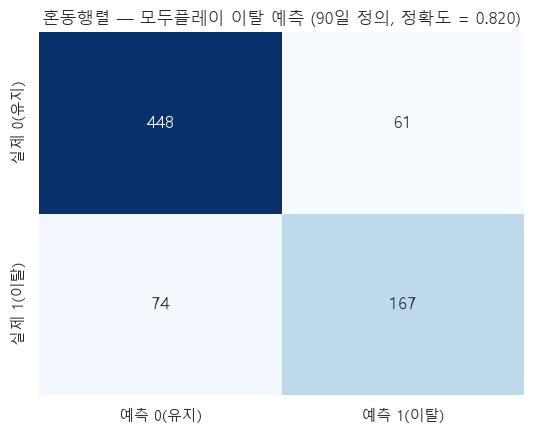

→ 대각선(왼쪽 위 ↘ 오른쪽 아래)이 맞힌 칸, 나머지 두 칸이 서로 다른 두 실수입니다.


In [4]:
# ─────────────────────────────────────────────
# [C4] Part 1 · 📊 데이터로 확인해 봅시다 — 90일 정의의 혼동행렬
# 혼동행렬 히트맵 (실행하면 네 칸이 색으로 구분된 격자가 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_90, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax)
ax.set_title("혼동행렬 — 모두플레이 이탈 예측 (90일 정의, "
             f"정확도 = {accuracy_score(y90_te, pred_90):.3f})")
plt.tight_layout()
plt.show()

print("→ 대각선(왼쪽 위 ↘ 오른쪽 아래)이 맞힌 칸, 나머지 두 칸이 서로 다른 두 실수입니다.")

In [5]:
# ─────────────────────────────────────────────
# [C3] Part 2 · 직접 계산해보기
# ─────────────────────────────────────────────

# 1) 네 칸의 나눗셈으로 정확도 직접 계산
accuracy_manual = (tp + tn) / (tp + tn + fp + fn)

print(f"수기 계산 정확도        = ({tp}+{tn})/({tp}+{tn}+{fp}+{fn}) = {accuracy_manual:.3f}")
print(f"accuracy_score() 결과   = {accuracy_score(y90_te, pred_90):.3f}")

# 2) 두 값이 같은지 확인
print(f"두 값이 같은가?          = {np.isclose(accuracy_manual, accuracy_score(y90_te, pred_90))}")

print()
print("─" * 50)
print("3) 가정: FN이 40개 늘고, TP가 40개 줄면?")
print("─" * 50)

# 원래 값
recall_original = tp / (tp + fn)

# 가정된 상황: TP -40, FN +40 (전체 개수는 변하지 않음)
tp_new = tp - 40
fn_new = fn + 40

accuracy_new = (tp_new + tn) / (tp_new + tn + fp + fn_new)
recall_new = tp_new / (tp_new + fn_new)

print(f"[원래]   정확도 = {accuracy_score(y90_te, pred_90):.3f}   재현율 = {recall_original:.3f}")
print(f"[변경 후] 정확도 = {accuracy_new:.3f}   재현율 = {recall_new:.3f}")
print()
print(f"정확도 변화폭 = {accuracy_new - accuracy_score(y90_te, pred_90):+.3f}")
print(f"재현율 변화폭 = {recall_new - recall_original:+.3f}")

수기 계산 정확도        = (167+448)/(167+448+61+74) = 0.820
accuracy_score() 결과   = 0.820
두 값이 같은가?          = True

──────────────────────────────────────────────────
3) 가정: FN이 40개 늘고, TP가 40개 줄면?
──────────────────────────────────────────────────
[원래]   정확도 = 0.820   재현율 = 0.693
[변경 후] 정확도 = 0.767   재현율 = 0.527

정확도 변화폭 = -0.053
재현율 변화폭 = -0.166


In [6]:
# ─────────────────────────────────────────────
# [C6] Part 2 · 📊 데이터로 확인해 봅시다 — 네 칸에서 지표를 손으로 계산
# 정밀도·재현율·F1을 정의대로 계산 → sklearn 결과와 대조 (실행하면 두 값이 나란히 출력됩니다)
# ─────────────────────────────────────────────
# 손계산 — 정의 그대로
precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print("네 칸:", f"TN={tn} FP={fp} FN={fn} TP={tp}")
print()
print(f"정밀도 = TP/(TP+FP) = {tp}/({tp}+{fp}) = {precision_manual:.4f}")
print(f"재현율 = TP/(TP+FN) = {tp}/({tp}+{fn}) = {recall_manual:.4f}")
print(f"F1     = 2PR/(P+R)                = {f1_manual:.4f}")
print()
print("sklearn 값과 대조")
print(f"  precision_score = {precision_score(y90_te, pred_90):.4f}")
print(f"  recall_score    = {recall_score(y90_te, pred_90):.4f}")
print(f"  f1_score        = {f1_score(y90_te, pred_90):.4f}")
print()
print("→ 손계산과 sklearn이 정확히 일치합니다. 지표는 네 칸의 나눗셈일 뿐입니다.")

네 칸: TN=448 FP=61 FN=74 TP=167

정밀도 = TP/(TP+FP) = 167/(167+61) = 0.7325
재현율 = TP/(TP+FN) = 167/(167+74) = 0.6929
F1     = 2PR/(P+R)                = 0.7122

sklearn 값과 대조
  precision_score = 0.7325
  recall_score    = 0.6929
  f1_score        = 0.7122

→ 손계산과 sklearn이 정확히 일치합니다. 지표는 네 칸의 나눗셈일 뿐입니다.


In [7]:
# ─────────────────────────────────────────────
# [C7] Part 2 · 📊 데이터로 확인해 봅시다 — 네 칸에서 지표를 손으로 계산
# classification_report — 클래스별 지표를 한 표로 (실행하면 지표 표가 출력됩니다)
# ─────────────────────────────────────────────
print(classification_report(
    y90_te, pred_90,
    target_names=["0 (유지)", "1 (이탈)"],
    digits=3,
))
print("support = 각 클래스의 실제 개수입니다. 지표를 해석할 때 반드시 함께 보세요.")

              precision    recall  f1-score   support

      0 (유지)      0.858     0.880     0.869       509
      1 (이탈)      0.732     0.693     0.712       241

    accuracy                          0.820       750
   macro avg      0.795     0.787     0.791       750
weighted avg      0.818     0.820     0.819       750

support = 각 클래스의 실제 개수입니다. 지표를 해석할 때 반드시 함께 보세요.


1. 1(이탈) 줄 이탈을 positive로
  - support = 241 은 750명중 실제 이탈한 고객 241명
  - recall = 0.693 은 실제 이탈 고객 241명중 모델이 69%(167명)을 잡아냄, 나머지 30%는 놓침(FN)
  - precision = 0.732 는 이탈할 것 같다고 예측한 사람들 중 73.2%가 진짜 이탈함, 나머지 26%는 헛경보(FP)
2. 0(유지) 줄 유지를 positive로
  - 유지고객 509명중 85%를 잘 맞췄고 유지할 것 같다고 예측한 85%가 실제 유지함
  - 0줄이 더 잘나오는 이유는 애초에 유지한 사람이 훨씬 많기 때문에 맞추기 더 쉽다, 이것이 **클래스 불균형 문제**이다
3. f1 - score
  - 재현율과 정밀도 둘다 좋아야 올라감
4. accuracy 
  - 정확도만 보면 좋아보임, 하지만 정확도만 보는건 함정이 있다. 그냥 찍기만 해도 509/750 이기때문에 69%가 나옴
5. macro avg, weighted avg
  - macro avg = 두 클래스(유지,이탈)을 동등한 비중으로 단순 평균 - 클래스 크기 무시(이탈 클래스도 유지 클래스만큼 중요하다 일때 씀)
  - weighted avg = 표본수(support)에 비례해서 가중평균 - 표본이 더 많은 유지 쪽에 가중치를 둠 (accuracy랑 거의 비슷하게 나옴)

In [8]:
def evaluate(name, tp, fp, fn, tn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    print(f"[{name}]")
    print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"  정밀도(Precision) = {tp}/({tp}+{fp}) = {precision:.3f}")
    print(f"  재현율(Recall)    = {tp}/({tp}+{fn}) = {recall:.3f}")
    print(f"  F1-score          = 2*({precision:.3f}*{recall:.3f})/({precision:.3f}+{recall:.3f}) = {f1:.3f}")
    print(f"  정확도(Accuracy)  = ({tp}+{tn})/전체 = {accuracy:.3f}")
    print()
    return {"precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy}

# 모델 A: TP=90, FP=10, FN=10, TN=890
result_A = evaluate("모델 A", tp=90, fp=10, fn=10, tn=890)

# 모델 B: TP=50, FP=0, FN=50, TN=900
result_B = evaluate("모델 B", tp=50, fp=0, fn=50, tn=900)

print("=" * 50)
print("비교 요약")
print("=" * 50)
print(f"{'지표':<12}{'모델 A':>10}{'모델 B':>10}{'차이(A-B)':>12}")
for key in ["accuracy", "precision", "recall", "f1"]:
    a_val = result_A[key]
    b_val = result_B[key]
    print(f"{key:<12}{a_val:>10.3f}{b_val:>10.3f}{a_val - b_val:>+12.3f}")

[모델 A]
  TP=90, FP=10, FN=10, TN=890
  정밀도(Precision) = 90/(90+10) = 0.900
  재현율(Recall)    = 90/(90+10) = 0.900
  F1-score          = 2*(0.900*0.900)/(0.900+0.900) = 0.900
  정확도(Accuracy)  = (90+890)/전체 = 0.980

[모델 B]
  TP=50, FP=0, FN=50, TN=900
  정밀도(Precision) = 50/(50+0) = 1.000
  재현율(Recall)    = 50/(50+50) = 0.500
  F1-score          = 2*(1.000*0.500)/(1.000+0.500) = 0.667
  정확도(Accuracy)  = (50+900)/전체 = 0.950

비교 요약
지표                모델 A      모델 B     차이(A-B)
accuracy         0.980     0.950      +0.030
precision        0.900     1.000      -0.100
recall           0.900     0.500      +0.400
f1               0.900     0.667      +0.233


2) 두 모델의 정확도를 각각 구합니다. 정확도로는 어느 쪽이 더 좋아 보입니까?
  - 0.980으로 모델 A가 약간 좋은 수준
3) 만약 이것이 "암 진단 선별검사"라면 어느 모델을 택해야 할까요? 이유를 한 줄로 적습니다.
  - 당연히 모델 A를 선택해야함, 그 이유는 FN이 10으로 적어서 실제로 병이 있는 환자를 잘 잡아내는 편이고 암 진단 선별검사에서는 FP가 낮아서 혹은 없어서 정밀도가 높게 나오는게 필요가 없음
  왜냐하면 양성이라고 예측했더라도 실제로는 음성이라면 그냥 재검사만 받으면 되기 때문에 상관없음, 하지만 FN이 높으면 목숨이 위험하기 때문에 최대한 FN을 낮춰서 재현율을 올려야함
  또한 F1-score도 0.900으로 모델 A가 훨씬 높음

In [9]:
# ─────────────────────────────────────────────
# [C9] Part 3 · 📊 데이터로 확인해 봅시다 — 거짓말을 눈으로
# 무조건 다수 찍기 vs 제대로 학습한 모델 (실행하면 두 모델의 지표가 나란히 출력됩니다)
# ─────────────────────────────────────────────
# ① 아무것도 배우지 않은 모델 — 무조건 다수 클래스(유지)로 찍기
dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
pred_dummy = dummy.predict(X_te)

# ② 제대로 학습한 로지스틱 회귀
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
).fit(X_tr, y_tr)
pred = model.predict(X_te)
proba = model.predict_proba(X_te)[:, 1]     # 이탈 확률 (Part 5에서 다시 씁니다)

rows = []
for name, p in [("① 무조건 유지로 찍기", pred_dummy), ("② 로지스틱 회귀", pred)]:
    rows.append({
        "모델": name,
        "정확도": accuracy_score(y_te, p),
        "정밀도": precision_score(y_te, p, zero_division=0),
        "재현율": recall_score(y_te, p),
        "F1": f1_score(y_te, p, zero_division=0),
    })
compare = pd.DataFrame(rows)
print(compare.round(3).to_string(index=False))
print()
print(f"참고 — 테스트셋 이탈 비율 = {y_te.mean():.3f}  (다수 클래스 비율 = {1 - y_te.mean():.3f})")
print(f"→ ①의 정확도는 다수 클래스 비율과 정확히 같습니다. 아무것도 배우지 않았는데도요.")

          모델   정확도   정밀도  재현율    F1
① 무조건 유지로 찍기 0.900 0.000 0.00 0.000
   ② 로지스틱 회귀 0.916 0.667 0.32 0.432

참고 — 테스트셋 이탈 비율 = 0.100  (다수 클래스 비율 = 0.900)
→ ①의 정확도는 다수 클래스 비율과 정확히 같습니다. 아무것도 배우지 않았는데도요.


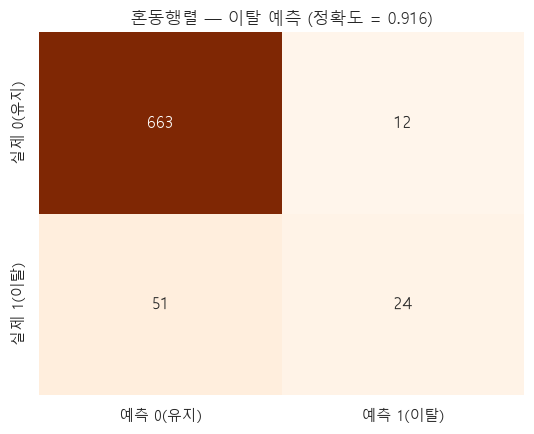

실제 이탈 고객 75명 중
  찾아낸 고객(TP)  = 24명
  놓친 고객(FN)    = 51명  ← 전체 이탈자의 68%
헛경보(FP)         = 12명  (쿠폰 낭비)

→ 정확도 0.916이라는 숫자에 이 51명이 숨어 있었습니다.


In [10]:
# ─────────────────────────────────────────────
# [C10] Part 3 · 📊 데이터로 확인해 봅시다 — 거짓말을 눈으로
# 불균형 데이터의 혼동행렬 — 놓침이 몇 명인지 (실행하면 격자와 놓침 인원이 출력됩니다)
# ─────────────────────────────────────────────
cm = confusion_matrix(y_te, pred)
tn_i, fp_i, fn_i, tp_i = cm.ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
            xticklabels=["예측 0(유지)", "예측 1(이탈)"],
            yticklabels=["실제 0(유지)", "실제 1(이탈)"], ax=ax)
ax.set_title(f"혼동행렬 — 이탈 예측 (정확도 = {accuracy_score(y_te, pred):.3f})")
plt.tight_layout()
plt.show()

churner = tp_i + fn_i
print(f"실제 이탈 고객 {churner}명 중")
print(f"  찾아낸 고객(TP)  = {tp_i}명")
print(f"  놓친 고객(FN)    = {fn_i}명  ← 전체 이탈자의 {fn_i / churner * 100:.0f}%")
print(f"헛경보(FP)         = {fp_i}명  (쿠폰 낭비)")
print()
print(f"→ 정확도 {accuracy_score(y_te, pred):.3f}이라는 숫자에 이 {fn_i}명이 숨어 있었습니다.")

In [11]:
# [C11] Part 3 · ⌨️ 백문이 불여일타! (3)
# ⌨️ 백문이 불여일타! (3) — 다수 클래스 비율이라는 숨은 출발선

# 여기에 코드를 작성하세요

churn_rates = [0.30, 0.10, 0.01, 0.001]

rows = []
for pi in churn_rates:
    dummy_accuracy = 1 - pi   # 무조건 다수(유지)로 찍었을 때의 정확도
    rows.append({
        "이탈률(π)": pi,
        "다수 클래스 비율(1-π)": dummy_accuracy,
        "무조건 다수 찍기 정확도": dummy_accuracy,
    })

baseline = pd.DataFrame(rows)
print(baseline.round(4).to_string(index=False))
print()
print("→ 이탈률이 낮아질수록(불균형이 심해질수록), 아무것도 안 배운 모델의 정확도가 100%에 가까워집니다.")
print("→ 즉 '정확도 99%'라는 보고를 받아도, 이탈률이 1%인 데이터라면 그건 바보 모델도 받는 점수입니다.")

 이탈률(π)  다수 클래스 비율(1-π)  무조건 다수 찍기 정확도
  0.300           0.700          0.700
  0.100           0.900          0.900
  0.010           0.990          0.990
  0.001           0.999          0.999

→ 이탈률이 낮아질수록(불균형이 심해질수록), 아무것도 안 배운 모델의 정확도가 100%에 가까워집니다.
→ 즉 '정확도 99%'라는 보고를 받아도, 이탈률이 1%인 데이터라면 그건 바보 모델도 받는 점수입니다.


- 1번 결과에서 봤듯 이탈률이 2%라면 "무조건 유지로 찍기"만 해도 정확도가 98%가 나오므로, 이 팀의 모델이 실제로 이탈 고객을 잘 찾아내는지는 정확도 98%라는 숫자만으로는 전혀 알 수 없다.
- 테스트 데이터의 양성비율은 몇%인가? 소수클래스에 대한 재현율과 정밀도는 얼마인가?

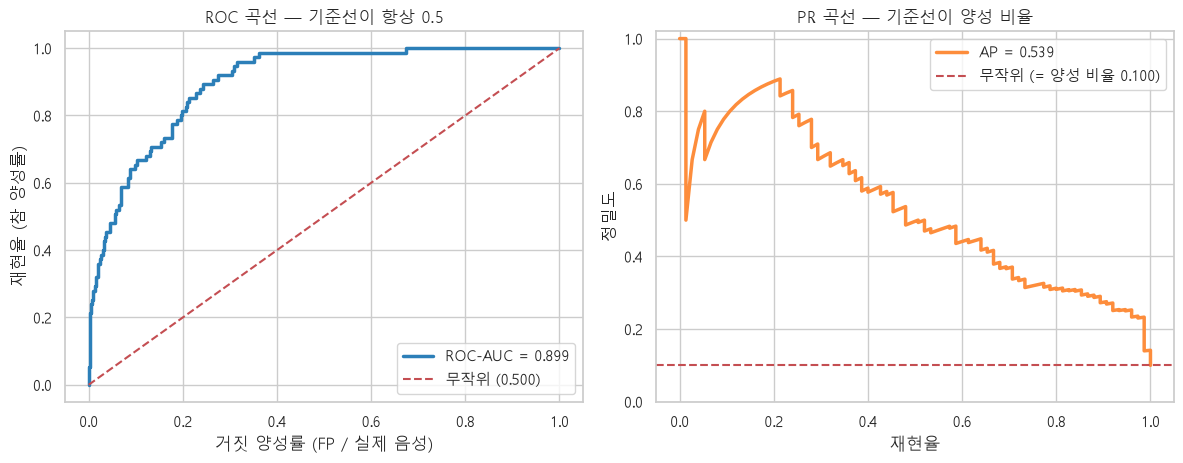

ROC-AUC = 0.899   (무작위 기준선 0.500 → 기준선의 1.8배)
AP      = 0.539   (양성 비율 0.100)


In [12]:
# ─────────────────────────────────────────────
# [C12] Part 4 · 📊 데이터로 확인해 봅시다 — 같은 모델, 두 곡선
# ROC곡선과 PR곡선을 나란히 (실행하면 두 곡선과 각각의 면적 점수가 나옵니다)
# ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)

roc_auc = roc_auc_score(y_te, proba)
ap = average_precision_score(y_te, proba)
baseline = y_te.mean()          # PR곡선의 무작위 기준선 = 양성 비율

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(fpr, tpr, lw=2.5, color="#2c7fb8", label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "r--", lw=1.5, label="무작위 (0.500)")
axes[0].set_xlabel("거짓 양성률 (FP / 실제 음성)")
axes[0].set_ylabel("재현율 (참 양성률)")
axes[0].set_title("ROC 곡선 — 기준선이 항상 0.5")
axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, lw=2.5, color="#fd8d3c", label=f"AP = {ap:.3f}")
axes[1].axhline(baseline, color="r", ls="--", lw=1.5,
                label=f"무작위 (= 양성 비율 {baseline:.3f})")
axes[1].set_xlabel("재현율")
axes[1].set_ylabel("정밀도")
axes[1].set_ylim(0, 1.02)
axes[1].set_title("PR 곡선 — 기준선이 양성 비율")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"ROC-AUC = {roc_auc:.3f}   (무작위 기준선 0.500 → 기준선의 {roc_auc / 0.5:.1f}배)")
print(f"AP      = {ap:.3f}   (양성 비율 {baseline:.3f})")

In [13]:
# ─────────────────────────────────────────────
# [C13] Part 4 · 📊 데이터로 확인해 봅시다 — 같은 모델, 두 곡선
# 이탈 비율을 30% → 2.7%로 낮추며 두 점수의 반응 비교 (실행하면 비교표가 나옵니다)
# ─────────────────────────────────────────────
# 절편(churn_base)만 바꿔 이탈 비율을 만듭니다. 피처 생성 규칙은 그대로입니다
BASE_BY_RATE = {0.30: 0.911, 0.10: -1.188, 0.05: -2.278, 0.027: -2.994}

records = []
for target, base in BASE_BY_RATE.items():
    d = make_moduplay(churn_base=base)
    Xa, ya = d[FEATURES], d["churn"]
    a_tr, a_te, ya_tr, ya_te = train_test_split(
        Xa, ya, test_size=0.25, random_state=RANDOM_STATE, stratify=ya)
    m = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    ).fit(a_tr, ya_tr)
    pa = m.predict_proba(a_te)[:, 1]
    records.append({
        "이탈 비율": f"{ya.mean():.1%}",
        "ROC-AUC": roc_auc_score(ya_te, pa),
        "AP": average_precision_score(ya_te, pa),
        "PR 기준선": ya_te.mean(),
    })

sweep = pd.DataFrame(records)
print(sweep.round(3).to_string(index=False))
print()
print("→ 이탈 비율이 30%에서 2.7%로 떨어지는 동안")
print(f"   ROC-AUC는 {sweep['ROC-AUC'].iloc[0]:.3f} → {sweep['ROC-AUC'].iloc[-1]:.3f}")
print(f"   AP는       {sweep['AP'].iloc[0]:.3f} → {sweep['AP'].iloc[-1]:.3f} (크게 하락)")

이탈 비율  ROC-AUC    AP  PR 기준선
30.0%    0.869 0.746   0.300
10.0%    0.899 0.539   0.100
 5.0%    0.895 0.345   0.049
 2.7%    0.810 0.155   0.027

→ 이탈 비율이 30%에서 2.7%로 떨어지는 동안
   ROC-AUC는 0.869 → 0.810
   AP는       0.746 → 0.155 (크게 하락)


In [14]:
# ─────────────────────────────────────────────
# 재현율 0.6 이상 구간에서 정밀도가 가장 높은 지점 찾기
# ─────────────────────────────────────────────
import numpy as np

# 1) 재현율이 0.6 이상인 지점만 골라내기
mask = rec >= 0.6

# 2) 그 중에서 정밀도가 가장 높은 지점의 인덱스 찾기
best_idx = np.argmax(prec[mask])

# 3) mask가 적용된 배열 안에서의 인덱스이므로, 원래 배열 값으로 매핑
best_precision = prec[mask][best_idx]
best_recall = rec[mask][best_idx]

print(f"재현율 0.6 이상인 지점 개수 = {mask.sum()}")
print(f"그 중 정밀도가 가장 높은 지점:")
print(f"  정밀도(Precision) = {best_precision:.3f}")
print(f"  재현율(Recall)    = {best_recall:.3f}")

재현율 0.6 이상인 지점 개수 = 649
그 중 정밀도가 가장 높은 지점:
  정밀도(Precision) = 0.449
  재현율(Recall)    = 0.640


2) 그 지점의 정밀도를 보고, "재현율 0.6을 확보하려면 무엇을 지불해야 하는가"를
   한 줄로 적습니다.
   - 재현율을 0.6이상을 확보하기 위해서는 정밀도를 0.449까지 포기해야한다. = 쿠폰을 배부한다고 했을때 예산의 54%정도는 어차피 안나갈 사람한테 쓰게된다
3) 무작위 모델의 기대 정밀도가 왜 양성 비율과 같아지는지 한 줄로 설명합니다.
    - 무작위 모델은 실제 이탈 여부와 무관하게 예측하므로, 예측된 양성 집단의 구성 비율이 전체 모집단의 양성 비율과 같아지고, 그게 곧 기대 정밀도가 된다.

In [15]:
# ─────────────────────────────────────────────
# [C15] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 임계값을 훑으며 지표 변화 추적 (실행하면 임계값별 지표·놓침·헛경보 표가 나옵니다)
# ─────────────────────────────────────────────
rows = []
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    p_t = (proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
    rows.append({
        "임계값": t,
        "정확도": accuracy_score(y_te, p_t),
        "정밀도": precision_score(y_te, p_t, zero_division=0),
        "재현율": recall_score(y_te, p_t),
        "F1": f1_score(y_te, p_t, zero_division=0),
        "놓침(FN)": fn_t,
        "헛경보(FP)": fp_t,
    })
sweep_t = pd.DataFrame(rows)
print(sweep_t.round(3).to_string(index=False))
print()
best = sweep_t.loc[sweep_t["F1"].idxmax()]
print(f"→ F1이 가장 높은 임계값은 {best['임계값']:.1f} (F1 = {best['F1']:.3f})")
print(f"  기본값 0.5의 F1은 {sweep_t['F1'].iloc[0]:.3f}이었습니다 — 기본값은 최적이 아닙니다.")

 임계값   정확도   정밀도   재현율    F1  놓침(FN)  헛경보(FP)
 0.5 0.916 0.667 0.320 0.432      51       12
 0.4 0.916 0.636 0.373 0.471      47       16
 0.3 0.905 0.529 0.480 0.503      39       32
 0.2 0.855 0.375 0.680 0.483      24       85
 0.1 0.780 0.294 0.853 0.437      11      154

→ F1이 가장 높은 임계값은 0.3 (F1 = 0.503)
  기본값 0.5의 F1은 0.432이었습니다 — 기본값은 최적이 아닙니다.


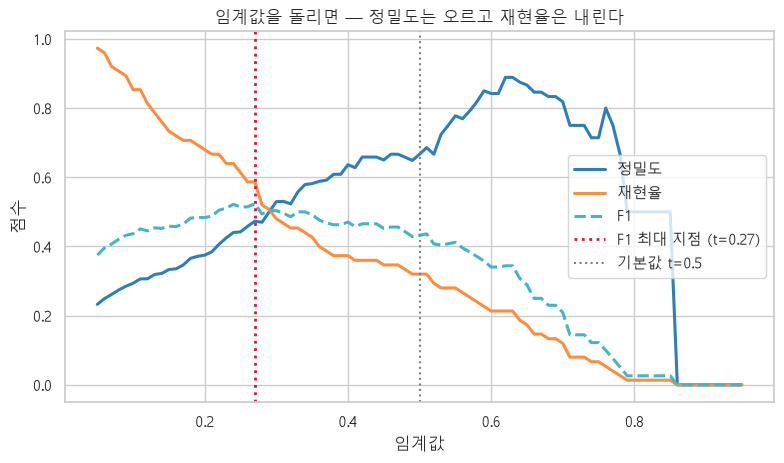

F1이 가장 높은 임계값 = 0.27 (F1 = 0.524)  ← 기본값 0.5보다 왼쪽입니다
→ 정밀도와 재현율이 정확히 반대로 움직입니다. 둘을 동시에 올리는 임계값은 없습니다.


In [16]:
# ─────────────────────────────────────────────
# [C16] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 임계값에 따른 정밀도·재현율·F1 (실행하면 세 곡선이 한 그림에 그려집니다)
# ─────────────────────────────────────────────
ts = np.linspace(0.05, 0.95, 91)
p_list, r_list, f_list = [], [], []
for t in ts:
    p_t = (proba >= t).astype(int)
    p_list.append(precision_score(y_te, p_t, zero_division=0))
    r_list.append(recall_score(y_te, p_t))
    f_list.append(f1_score(y_te, p_t, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(ts, p_list, lw=2.2, label="정밀도", color="#2c7fb8")
ax.plot(ts, r_list, lw=2.2, label="재현율", color="#fd8d3c")
ax.plot(ts, f_list, lw=2.2, label="F1", color="#41b6c4", ls="--")
best_t = ts[int(np.argmax(f_list))]
ax.axvline(best_t, color="crimson", ls=":", lw=2,
           label=f"F1 최대 지점 (t={best_t:.2f})")
ax.axvline(0.5, color="gray", ls=":", lw=1.5, label="기본값 t=0.5")
ax.set_xlabel("임계값")
ax.set_ylabel("점수")
ax.set_title("임계값을 돌리면 — 정밀도는 오르고 재현율은 내린다")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print(f"F1이 가장 높은 임계값 = {best_t:.2f} (F1 = {max(f_list):.3f})  ← 기본값 0.5보다 왼쪽입니다")
print("→ 정밀도와 재현율이 정확히 반대로 움직입니다. 둘을 동시에 올리는 임계값은 없습니다.")

In [17]:
# ─────────────────────────────────────────────
# [C17] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# 비용으로 임계값 정하기 (실행하면 임계값별 총비용과 최소 지점이 나옵니다)
# ─────────────────────────────────────────────
# 모두플레이 마케팅팀이 알려준 숫자
COST_FN = 10   # 놓침 1건 = 이탈로 잃는 고객 생애가치 10만원
COST_FP = 2    # 헛경보 1건 = 불필요한 방어 쿠폰 2만원

rows = []
for t in np.arange(0.05, 0.85, 0.05):
    p_t = (proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
    rows.append({
        "임계값": round(t, 2),
        "놓침(FN)": fn_t,
        "헛경보(FP)": fp_t,
        "총비용(만원)": fn_t * COST_FN + fp_t * COST_FP,
    })
cost = pd.DataFrame(rows)
print(f"놓침 1건 = {COST_FN}만원 / 헛경보 1건 = {COST_FP}만원 (비용비 {COST_FN // COST_FP}:1)")
print()
print(cost[cost["임계값"] <= 0.55].to_string(index=False))

opt = cost.loc[cost["총비용(만원)"].idxmin()]
print()
print(f"→ 총비용이 최소인 임계값 = {opt['임계값']:.2f}  (총비용 {int(opt['총비용(만원)'])}만원)")
print(f"  기본값 0.5의 총비용은 {int(cost.loc[cost['임계값'] == 0.5, '총비용(만원)'].iloc[0])}만원이었습니다.")

놓침 1건 = 10만원 / 헛경보 1건 = 2만원 (비용비 5:1)

 임계값  놓침(FN)  헛경보(FP)  총비용(만원)
0.05       2      241      502
0.10      11      154      418
0.15      20      110      420
0.20      24       85      410
0.25      29       58      406
0.30      39       32      454
0.35      43       23      476
0.40      47       16      502
0.45      49       14      518
0.50      51       12      534
0.55      54        6      552

→ 총비용이 최소인 임계값 = 0.25  (총비용 406만원)
  기본값 0.5의 총비용은 534만원이었습니다.


"임계값을 0.25로 설정했습니다. 놓침 1건을 10만원, 헛경보 1건을 2만원으로 놓고 계산했을 때 예상 손실이 406만원으로 최소이며, 기본값 0.5(534만원)보다 128만원 낮습니다."

In [18]:
# ─────────────────────────────────────────────
# [C18] Part 5 · 📊 데이터로 확인해 봅시다 — 손잡이를 돌려 보기
# class_weight 보정 전후 — 계층 5겹 교차 검증 (실행하면 네 지표의 전후 비교표가 나옵니다)
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for cw, label in [(None, "보정 없음"), ("balanced", "class_weight='balanced'")]:
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight=cw, random_state=RANDOM_STATE),
    )
    rows.append({
        "설정": label,
        "재현율": cross_val_score(pipe, X, y, cv=cv, scoring="recall").mean(),
        "정밀도": cross_val_score(pipe, X, y, cv=cv, scoring="precision").mean(),
        "F1": cross_val_score(pipe, X, y, cv=cv, scoring="f1").mean(),
        "AP": cross_val_score(pipe, X, y, cv=cv, scoring="average_precision").mean(),
    })
cw_compare = pd.DataFrame(rows)
print("계층 5겹 교차 검증 평균")
print(cw_compare.round(3).to_string(index=False))
print()
d_recall = cw_compare["재현율"].iloc[1] - cw_compare["재현율"].iloc[0]
d_prec = cw_compare["정밀도"].iloc[1] - cw_compare["정밀도"].iloc[0]
d_ap = cw_compare["AP"].iloc[1] - cw_compare["AP"].iloc[0]
print(f"→ 재현율 변화: {d_recall:+.3f}   (약 {cw_compare['재현율'].iloc[1] / cw_compare['재현율'].iloc[0]:.1f}배)")
print(f"  정밀도 변화: {d_prec:+.3f}   ← 재현율을 산 값입니다")
print(f"  AP 변화: {d_ap:+.3f}   ← 순위 요약 성능의 변화를 함께 확인합니다")

계층 5겹 교차 검증 평균
                     설정  재현율   정밀도    F1    AP
                  보정 없음 0.29 0.672 0.405 0.532
class_weight='balanced' 0.81 0.297 0.434 0.534

→ 재현율 변화: +0.520   (약 2.8배)
  정밀도 변화: -0.375   ← 재현율을 산 값입니다
  AP 변화: +0.002   ← 순위 요약 성능의 변화를 함께 확인합니다


In [19]:
# ─────────────────────────────────────────────
# [C17] Part 6 · 비용비가 바뀌면 최적 임계값은 어디로?
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def find_optimal_threshold(proba, y_te, cost_fn, cost_fp, label):
    rows = []
    for t in np.arange(0.05, 0.85, 0.05):
        p_t = (proba >= t).astype(int)
        tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_te, p_t).ravel()
        rows.append({
            "임계값": round(t, 2),
            "놓침(FN)": fn_t,
            "헛경보(FP)": fp_t,
            "총비용(만원)": fn_t * cost_fn + fp_t * cost_fp,
        })
    cost = pd.DataFrame(rows)
    opt = cost.loc[cost["총비용(만원)"].idxmin()]

    print(f"[{label}]  놓침 1건={cost_fn}만원 / 헛경보 1건={cost_fp}만원 (비용비 {cost_fn/cost_fp:.1f}:1)")
    print(cost[cost["임계값"] <= 0.55].to_string(index=False))
    print(f"→ 총비용 최소 임계값 = {opt['임계값']:.2f}  (총비용 {int(opt['총비용(만원)'])}만원)")
    print()
    return opt["임계값"]

# 원래 기준 ([C17]) — 비교용
t0 = find_optimal_threshold(proba, y_te, cost_fn=10, cost_fp=2, label="원래: FN=10, FP=2")

# 1) 쿠폰 단가 인상: COST_FP 2 → 5
t1 = find_optimal_threshold(proba, y_te, cost_fn=10, cost_fp=5, label="1) 쿠폰 단가 인상: FN=10, FP=5")

# 2) 고객 생애가치 재평가: COST_FN 10 → 30
t2 = find_optimal_threshold(proba, y_te, cost_fn=30, cost_fp=2, label="2) 생애가치 재평가: FN=30, FP=2")

print("=" * 50)
print("비용비와 최적 임계값 비교")
print("=" * 50)
print(f"원래(비용비 5.0:1)      → 최적 임계값 = {t0:.2f}")
print(f"1) 비용비 2.0:1로 감소  → 최적 임계값 = {t1:.2f}")
print(f"2) 비용비 15.0:1로 증가 → 최적 임계값 = {t2:.2f}")

[원래: FN=10, FP=2]  놓침 1건=10만원 / 헛경보 1건=2만원 (비용비 5.0:1)
 임계값  놓침(FN)  헛경보(FP)  총비용(만원)
0.05       2      241      502
0.10      11      154      418
0.15      20      110      420
0.20      24       85      410
0.25      29       58      406
0.30      39       32      454
0.35      43       23      476
0.40      47       16      502
0.45      49       14      518
0.50      51       12      534
0.55      54        6      552
→ 총비용 최소 임계값 = 0.25  (총비용 406만원)

[1) 쿠폰 단가 인상: FN=10, FP=5]  놓침 1건=10만원 / 헛경보 1건=5만원 (비용비 2.0:1)
 임계값  놓침(FN)  헛경보(FP)  총비용(만원)
0.05       2      241     1225
0.10      11      154      880
0.15      20      110      750
0.20      24       85      665
0.25      29       58      580
0.30      39       32      550
0.35      43       23      545
0.40      47       16      550
0.45      49       14      560
0.50      51       12      570
0.55      54        6      570
→ 총비용 최소 임계값 = 0.35  (총비용 545만원)

[2) 생애가치 재평가: FN=30, FP=2]  놓침 1건=30만원 / 헛경보 1건=2만원 (비용비 15.0:1)
 임계값

즉, "비용비(FN 비용/FP 비용)가 커질수록 최적 임계값은 낮아지고, 비용비가 작아질수록 최적 임계값은 높아진다